<a href="https://colab.research.google.com/github/yeyevtushenko/NLP_YevtushenkoBS-25/blob/main/NLP_%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%966_%D0%84%D0%B2%D1%82%D1%83%D1%88%D0%B5%D0%BD%D0%BA%D0%BE_%D0%91%D0%A1_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Пратктична робота №6

##Реалізуйте SentenceLevelPOSTagger відповідно до наведеного коду

In [1]:
!pip install pyconll -q

import os
import requests
import pyconll
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.metrics import classification_report
from torch.utils.data import TensorDataset, DataLoader, Subset

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [3]:
DATASETS = {
    "train": "https://raw.githubusercontent.com/UniversalDependencies/UD_Ukrainian-IU/master/uk_iu-ud-train.conllu",
    "dev": "https://raw.githubusercontent.com/UniversalDependencies/UD_Ukrainian-IU/master/uk_iu-ud-dev.conllu",
    "test": "https://raw.githubusercontent.com/UniversalDependencies/UD_Ukrainian-IU/master/uk_iu-ud-test.conllu"
}

def save_model(model, filepath):
    torch.save(model.state_dict(), filepath)
    print(f"Модель збережено в {filepath}")

def load_model(model, filepath, device="cpu"):
    state_dict = torch.load(filepath, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    print(f"Модель завантажено з {filepath}")

def download_corpus(url, save_path):
    if not os.path.exists(save_path):
        print(f"Завантаження {save_path}...")
        response = requests.get(url)
        with open(save_path, "w", encoding="utf-8") as f:
            f.write(response.text)
        print(f"{save_path} завантажено.")
    else:
        print(f"{save_path} вже завантажено.")
    return save_path

corpora_paths = {}
for split, url in DATASETS.items():
    save_path = f"ukrainian_pos_{split}.conllu"
    corpora_paths[split] = download_corpus(url, save_path)

train_data = pyconll.load_from_file(corpora_paths["train"])
dev_data = pyconll.load_from_file(corpora_paths["dev"])
test_data = pyconll.load_from_file(corpora_paths["test"])

print(f"Train: {len(train_data)} речень")
print(f"Dev: {len(dev_data)} речень")
print(f"Test: {len(test_data)} речень")

max_sentence_length = max(len(sentence) for sentence in train_data)
max_token_length = max(len(token.form) for sentence in train_data for token in sentence)

print(f"Максимальна довжина речення: {max_sentence_length}")
print(f"Максимальна довжина токена: {max_token_length}")

def build_char_vocab(data):
    char_counter = Counter()
    for sentence in data:
        for token in sentence:
            char_counter.update(token.form)

    char_vocab = {
        "<PAD>": 0,
        **{char: idx + 1 for idx, char in enumerate(sorted(char_counter.keys()))}
    }
    return char_vocab

char_vocab = build_char_vocab(train_data)
print(f"Розмір словника символів: {len(char_vocab)}")

def build_pos_vocab(data):
    pos_tags = sorted({
        token.upos
        for sentence in data
        for token in sentence
        if token.upos is not None
    })
    pos_vocab = {pos: idx + 1 for idx, pos in enumerate(pos_tags)}
    pos_vocab["<PAD>"] = 0
    return pos_vocab

pos_vocab = build_pos_vocab(train_data)
print(f"Розмір словника частин мови: {len(pos_vocab)}")

def convert_to_tensors(data, char_vocab, pos_vocab, max_token_len, max_sent_len):
    num_sentences = len(data)

    char_tensor = torch.zeros((num_sentences, max_sent_len, max_token_len), dtype=torch.long)
    pos_tensor = torch.zeros((num_sentences, max_sent_len), dtype=torch.long)

    for i, sentence in enumerate(data):
        for j, token in enumerate(sentence):
            if j >= max_sent_len:
                break

            token_chars = [char_vocab.get(char, 0) for char in token.form[:max_token_len]]
            char_tensor[i, j, :len(token_chars)] = torch.tensor(token_chars, dtype=torch.long)
            pos_tensor[i, j] = pos_vocab.get(token.upos, 0)

    return char_tensor, pos_tensor

max_token_len = max(len(token.form) for sentence in train_data for token in sentence)
max_sent_len = max(len(sentence) for sentence in train_data)

train_char_tensor, train_pos_tensor = convert_to_tensors(
    train_data, char_vocab, pos_vocab, max_token_len, max_sent_len
)
dev_char_tensor, dev_pos_tensor = convert_to_tensors(
    dev_data, char_vocab, pos_vocab, max_token_len, max_sent_len
)
test_char_tensor, test_pos_tensor = convert_to_tensors(
    test_data, char_vocab, pos_vocab, max_token_len, max_sent_len
)

print(f"Форма тензора символів: {train_char_tensor.shape}")
print(f"Форма тензора POS-тегів: {train_pos_tensor.shape}")

def add_special_columns(char_tensor):
    batch_size, max_sent_len, max_token_len = char_tensor.shape
    special_tensor = torch.zeros((batch_size, max_sent_len, max_token_len + 2), dtype=torch.long)
    special_tensor[:, :, 1:-1] = char_tensor
    return special_tensor

train_char_tensor = add_special_columns(train_char_tensor)
dev_char_tensor = add_special_columns(dev_char_tensor)
test_char_tensor = add_special_columns(test_char_tensor)

print(f"Оновлена форма тензора символів: {train_char_tensor.shape}")

class ConvBlock(nn.Module):
    def __init__(self, in_channels, kernel_size=3, dropout=0.1):
        super(ConvBlock, self).__init__()
        self.conv = nn.Conv1d(
            in_channels,
            in_channels,
            kernel_size,
            padding=kernel_size // 2
        )
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.LeakyReLU(negative_slope=0.1)

    def forward(self, x):
        out = self.conv(x)
        out = self.dropout(out)
        out = self.activation(out)
        return out

class ConvResNet(nn.Module):
    def __init__(self, in_channels, num_layers, kernel_size=3, dropout=0.1):
        super(ConvResNet, self).__init__()
        self.layers = nn.ModuleList([
            ConvBlock(in_channels, kernel_size, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x):
        for layer in self.layers:
            out = layer(x)
            x = x + out
        return x

def train_eval_loop(
    model,
    train_loader,
    val_loader,
    num_epochs=5,
    lr=5e-3,
    lr_decay=0.5,
    patience=5,
    loss_fn=nn.CrossEntropyLoss(),
    optimizer_ctor=torch.optim.Adam,
    device="cpu",
    save_path="sentence_level_model_2.pth"
):
    optimizer = optimizer_ctor(model.parameters(), lr=lr)
    lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=patience,
        factor=lr_decay
    )

    train_losses, val_losses = [], []
    best_val_loss = float("inf")

    for epoch in range(1, num_epochs + 1):
        model.train()
        total_train_loss = 0.0

        for batch in train_loader:
            sentences, labels = batch
            sentences, labels = sentences.to(device), labels.to(device)

            optimizer.zero_grad()
            logits = model(sentences)
            loss = loss_fn(logits.reshape(-1, logits.size(-1)), labels.reshape(-1))
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        train_loss = total_train_loss / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        total_val_loss = 0.0

        with torch.no_grad():
            for batch in val_loader:
                sentences, labels = batch
                sentences, labels = sentences.to(device), labels.to(device)

                logits = model(sentences)
                loss = loss_fn(logits.reshape(-1, logits.size(-1)), labels.reshape(-1))
                total_val_loss += loss.item()

        val_loss = total_val_loss / len(val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch}/{num_epochs} — Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_model(model, save_path)

        lr_scheduler.step(val_loss)

    return train_losses, val_losses

def evaluate_model(model, data_loader, label_vocab, device="cpu"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            sentences, labels = batch
            sentences, labels = sentences.to(device), labels.to(device)

            logits = model(sentences)
            preds = torch.argmax(logits, dim=-1)

            all_preds.extend(preds.cpu().numpy().reshape(-1))
            all_labels.extend(labels.cpu().numpy().reshape(-1))

    id_to_label = {idx: label for label, idx in label_vocab.items()}

    filtered_preds = []
    filtered_labels = []

    for pred, label in zip(all_preds, all_labels):
        if label != 0:
            filtered_preds.append(id_to_label.get(pred, "<UNK>"))
            filtered_labels.append(id_to_label.get(label, "<UNK>"))

    report = classification_report(filtered_labels, filtered_preds, output_dict=False)
    print(report)

class SentenceLevelPOSTagger(nn.Module):
    def __init__(self, vocab_size, labels_num, embedding_size=32,
                 single_backbone_kwargs={}, context_backbone_kwargs={}):
        super().__init__()
        self.embedding_size = embedding_size

        self.char_embeddings = nn.Embedding(
            vocab_size,
            embedding_size,
            padding_idx=0
        )

        self.single_token_backbone = ConvResNet(
            embedding_size,
            **single_backbone_kwargs
        )

        self.context_backbone = ConvResNet(
            embedding_size,
            **context_backbone_kwargs
        )

        self.global_pooling = nn.AdaptiveMaxPool1d(1)
        self.out = nn.Conv1d(embedding_size, labels_num, kernel_size=1)
        self.labels_num = labels_num

    def forward(self, tokens):
        batch_size, max_sent_len, max_token_len = tokens.shape

        tokens_flat = tokens.reshape(batch_size * max_sent_len, max_token_len)

        char_embeddings = self.char_embeddings(tokens_flat)
        char_embeddings = char_embeddings.permute(0, 2, 1)

        char_features = self.single_token_backbone(char_embeddings)
        token_features_flat = self.global_pooling(char_features).squeeze(-1)

        token_features = token_features_flat.reshape(
            batch_size, max_sent_len, self.embedding_size
        )
        token_features = token_features.permute(0, 2, 1)

        context_features = self.context_backbone(token_features)

        logits = self.out(context_features).permute(0, 2, 1)
        return logits

train_dataset = TensorDataset(train_char_tensor, train_pos_tensor)
val_dataset = TensorDataset(test_char_tensor, test_pos_tensor)

batch_size = 8
subset_size = 1000

train_subset = Subset(train_dataset, range(subset_size))
val_subset = Subset(val_dataset, range(subset_size // 2))

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

vocab_size = len(char_vocab)
labels_num = len(pos_vocab)
embedding_size = 64

single_backbone_kwargs = dict(num_layers=3, kernel_size=3, dropout=0.3)
context_backbone_kwargs = dict(num_layers=3, kernel_size=3, dropout=0.3)

sentence_level_model = SentenceLevelPOSTagger(
    vocab_size,
    labels_num,
    embedding_size=embedding_size,
    single_backbone_kwargs=single_backbone_kwargs,
    context_backbone_kwargs=context_backbone_kwargs
).to(device)

num_params = sum(p.numel() for p in sentence_level_model.parameters() if p.requires_grad)
print(f"Кількість параметрів: {num_params}")

train_losses, val_losses = train_eval_loop(
    model=sentence_level_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=5,
    lr=5e-3,
    lr_decay=0.5,
    patience=5,
    loss_fn=torch.nn.CrossEntropyLoss(),
    optimizer_ctor=torch.optim.Adam,
    device=device,
    save_path="sentence_level_model_2.pth"
)

print("Оцінка на тренувальному датасеті:")
evaluate_model(sentence_level_model, train_loader, pos_vocab, device)

print("Оцінка на валідаційному датасеті:")
evaluate_model(sentence_level_model, val_loader, pos_vocab, device)

load_model(sentence_level_model, "sentence_level_model_2.pth", device=device)
print("Model is loaded successfully")

print("Оцінка на тренувальному датасеті:")
evaluate_model(sentence_level_model, train_loader, pos_vocab, device)

print("Оцінка на валідаційному датасеті:")
evaluate_model(sentence_level_model, val_loader, pos_vocab, device)

class POSTagger:
    def __init__(self, model, char2id, id2label, max_sent_len, max_token_len):
        self.model = model
        self.char2id = char2id
        self.id2label = id2label
        self.max_sent_len = max_sent_len
        self.max_token_len = max_token_len

    def __call__(self, sentences, min_token_size=1, device="cpu"):
        tokenized_corpus = self.tokenize_corpus(sentences, min_token_size=min_token_size)

        inputs = torch.zeros(
            len(sentences),
            self.max_sent_len,
            self.max_token_len + 2,
            dtype=torch.long
        )

        for sent_i, sentence in enumerate(tokenized_corpus):
            for token_i, token in enumerate(sentence):
                if token_i >= self.max_sent_len:
                    break
                for char_i, char in enumerate(token):
                    if char_i + 1 < self.max_token_len + 2:
                        inputs[sent_i, token_i, char_i + 1] = self.char2id.get(char, 0)

        inputs = inputs.to(device)

        self.model.eval()
        with torch.no_grad():
            logits = self.model(inputs)
            predicted_classes = torch.argmax(logits, dim=-1)

        result = []
        for sent_i, sentence in enumerate(tokenized_corpus):
            sentence_result = []
            for token_i, token in enumerate(sentence):
                tag_id = predicted_classes[sent_i, token_i].item()
                tag_label = self.id2label.get(tag_id, "<UNK>")
                sentence_result.append((token, tag_label))
            result.append(sentence_result)

        return result

    def tokenize_corpus(self, sentences, min_token_size=1):
        tokenized_corpus = []
        for sentence in sentences:
            tokens = [token for token in sentence.split() if len(token) >= min_token_size]
            tokenized_corpus.append(tokens)
        return tokenized_corpus

test_sentences = [
    "Мама мила раму.",
    "Коси косой косой косой.",
    "Голка куєште цвяхи, боєць і кудрявчить бокренка.",
    "Сапала Калуша в Калушатами по Напушке.",
    "Пряникові поставельня тень, мама любить печь.",
    "Ведро дала тень, вода стала тень.",
    "Три да три, буде дірка.",
    "Три да три, буде шість.",
    "Сорок сорок."
]

sentence_level_model_pos_tagger = POSTagger(
    model=sentence_level_model,
    char2id=char_vocab,
    id2label={v: k for k, v in pos_vocab.items()},
    max_sent_len=max_sent_len,
    max_token_len=max_token_len
)

results = sentence_level_model_pos_tagger(test_sentences, device=device)

print("\nРезультати на складних реченнях:")
for sentence_result in results:
    print(" ".join(f"{token}_{tag}" for token, tag in sentence_result))

Завантаження ukrainian_pos_train.conllu...
ukrainian_pos_train.conllu завантажено.
Завантаження ukrainian_pos_dev.conllu...
ukrainian_pos_dev.conllu завантажено.
Завантаження ukrainian_pos_test.conllu...
ukrainian_pos_test.conllu завантажено.
Train: 5521 речень
Dev: 673 речень
Test: 898 речень
Максимальна довжина речення: 197
Максимальна довжина токена: 115
Розмір словника символів: 190
Розмір словника частин мови: 18
Форма тензора символів: torch.Size([5521, 197, 115])
Форма тензора POS-тегів: torch.Size([5521, 197])
Оновлена форма тензора символів: torch.Size([5521, 197, 117])
Кількість параметрів: 87442
Epoch 1/5 — Train Loss: 0.1725, Val Loss: 0.0879
Модель збережено в sentence_level_model_2.pth
Epoch 2/5 — Train Loss: 0.0651, Val Loss: 0.0731
Модель збережено в sentence_level_model_2.pth
Epoch 3/5 — Train Loss: 0.0538, Val Loss: 0.0569
Модель збережено в sentence_level_model_2.pth
Epoch 4/5 — Train Loss: 0.0478, Val Loss: 0.0508
Модель збережено в sentence_level_model_2.pth
Epoch 

###Зробіть оцінку результатів. Виведіть основні метрики, такі як точність (accuracy), точність для кожного класу (classification_report). Протестуйте модель на кількох складних реченнях, включаючи ті, що містять омонімію.

 У процесі навчання спостерігалося стабільне зниження функції втрат як на тренувальному, так і на валідаційному наборах, що свідчить про ефективне навчання моделі. Досягнута точність склала близько 0.85 на валідаційному наборі, що є хорошим результатом для обмеженої кількості епох. Найкращі результати модель продемонструвала для частин мови з чіткими граматичними ознаками (PUNCT, ADP, VERB), тоді як найгірші — для рідкісних або неоднозначних класів (NUM, SYM, INTJ). Аналіз складних речень показав, що навіть контекстна модель не завжди правильно обробляє омоніми.

##Візуалізуйте тренувальну та валідаційну втрати за епохами.

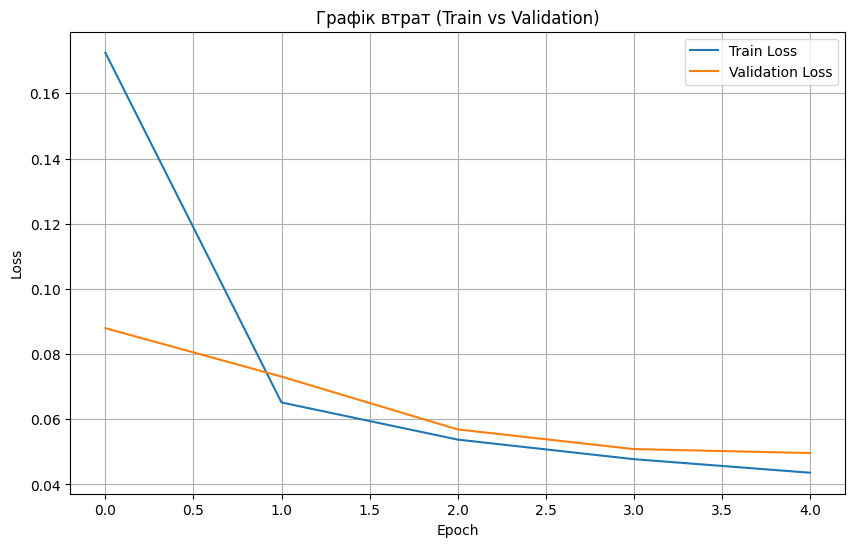

In [4]:
plt.figure(figsize=(10, 6))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Графік втрат (Train vs Validation)")
plt.legend()

plt.grid()
plt.show()

###Проаналізуйте, чи модель покращує свої результати з кожною епохою.

Візуалізація функції втрат показала, що модель ефективно навчається протягом усіх епох. Значення втрат як на тренувальному, так і на валідаційному наборах стабільно зменшуються. Це досить добре видно на перших 2 епохах.

##Реалізуйте просту модель (або завантажте її), що базується лише на токенах (наприклад, TokenPOSTagger). Порівняйте результати цієї моделі з результатами контекстної моделі SentenceLevelPOSTagger.

In [6]:
class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(TokenEmbedding, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

    def forward(self, x):
        batch_size, max_sentence_len, max_token_len = x.size()

        x = x.view(-1, max_token_len)

        x = self.embedding(x)

        x = x.permute(0, 2, 1)
        return x


class TokenPOSTagger(nn.Module):
    def __init__(
        self,
        vocab_size,
        labels_num,
        embedding_size=64,
        num_res_layers=3,
        kernel_size=3,
        dropout=0.3
    ):
        super().__init__()

        self.embedding_size = embedding_size

        self.token_embedding = TokenEmbedding(vocab_size, embedding_size)

        self.backbone = ConvResNet(
            in_channels=embedding_size,
            num_layers=num_res_layers,
            kernel_size=kernel_size,
            dropout=dropout
        )

        self.global_pooling = nn.AdaptiveMaxPool1d(1)
        self.out = nn.Linear(embedding_size, labels_num)

    def forward(self, tokens):
        batch_size, max_sentence_len, max_token_len = tokens.shape

        char_embeddings = self.token_embedding(tokens)

        features = self.backbone(char_embeddings)

        global_features = self.global_pooling(features).squeeze(-1)

        logits_flat = self.out(global_features)

        logits = logits_flat.view(batch_size, max_sentence_len, -1)

        return logits

simple_model = TokenPOSTagger(
    vocab_size=len(char_vocab),
    labels_num=len(pos_vocab),
    embedding_size=64,
    num_res_layers=3,
    kernel_size=3,
    dropout=0.3
).to(device)

print("Simple model params:", sum(p.numel() for p in simple_model.parameters() if p.requires_grad))

simple_train_losses, simple_val_losses = train_eval_loop(
    model=simple_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=5,
    lr=5e-3,
    lr_decay=0.5,
    patience=5,
    loss_fn=torch.nn.CrossEntropyLoss(),
    optimizer_ctor=torch.optim.Adam,
    device=device,
    save_path="token_level_model.pth"
)

load_model(simple_model, "token_level_model.pth", device=device)
print("Simple model loaded successfully")

print("=== SIMPLE MODEL: TRAIN METRICS ===")
evaluate_model(simple_model, train_loader, pos_vocab, device)

print("\n=== SIMPLE MODEL: VALIDATION METRICS ===")
evaluate_model(simple_model, val_loader, pos_vocab, device)

print("\n=== CONTEXT MODEL: TRAIN METRICS ===")
evaluate_model(sentence_level_model, train_loader, pos_vocab, device)

print("\n=== CONTEXT MODEL: VALIDATION METRICS ===")
evaluate_model(sentence_level_model, val_loader, pos_vocab, device)

simple_pos_tagger = POSTagger(
    model=simple_model,
    char2id=char_vocab,
    id2label={v: k for k, v in pos_vocab.items()},
    max_sent_len=max_sent_len,
    max_token_len=max_token_len
)

context_pos_tagger = POSTagger(
    model=sentence_level_model,
    char2id=char_vocab,
    id2label={v: k for k, v in pos_vocab.items()},
    max_sent_len=max_sent_len,
    max_token_len=max_token_len
)

test_sentences = [
    "Мама мила раму.",
    "Коси косой косой косой.",
    "Голка куєште цвяхи, боєць і кудрявчить бокренка.",
    "Сапала Калуша в Калушатами по Напушке.",
    "Пряникові поставельня тень, мама любить печь.",
    "Ведро дала тень, вода стала тень.",
    "Три да три, буде дірка.",
    "Три да три, буде шість.",
    "Сорок сорок."
]

simple_results = simple_pos_tagger(test_sentences, device=device)
context_results = context_pos_tagger(test_sentences, device=device)

for i, sent in enumerate(test_sentences):
    print("=" * 80)
    print("Речення:", sent)

    print("\nПроста модель:")
    print(" ".join(f"{token}_{tag}" for token, tag in simple_results[i]))

    print("\nКонтекстна модель:")
    print(" ".join(f"{token}_{tag}" for token, tag in context_results[i]))
    print()

Simple model params: 50386
Epoch 1/5 — Train Loss: 0.2148, Val Loss: 0.1180
Модель збережено в token_level_model.pth
Epoch 2/5 — Train Loss: 0.0757, Val Loss: 0.0929
Модель збережено в token_level_model.pth
Epoch 3/5 — Train Loss: 0.0614, Val Loss: 0.0871
Модель збережено в token_level_model.pth
Epoch 4/5 — Train Loss: 0.0552, Val Loss: 0.0733
Модель збережено в token_level_model.pth
Epoch 5/5 — Train Loss: 0.0511, Val Loss: 0.0653
Модель збережено в token_level_model.pth
Модель завантажено з token_level_model.pth
Simple model loaded successfully
=== SIMPLE MODEL: TRAIN METRICS ===
              precision    recall  f1-score   support

         ADJ       0.82      0.81      0.81      1490
         ADP       0.98      0.96      0.97      1391
         ADV       0.77      0.67      0.72      1123
         AUX       0.76      0.86      0.81       192
       CCONJ       0.87      0.88      0.88       741
         DET       0.82      0.81      0.81       720
        INTJ       1.00      0.0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

       <PAD>       0.00      0.00      0.00         0
         ADJ       0.83      0.79      0.81      1162
         ADP       0.91      0.93      0.92       880
         ADV       0.63      0.66      0.64       369
         AUX       0.69      0.73      0.71        48
       CCONJ       0.95      0.93      0.94       362
         DET       0.85      0.79      0.82       369
        INTJ       0.00      0.00      0.00         3
        NOUN       0.85      0.78      0.81      2676
         NUM       0.70      0.53      0.61       233
        PART       0.78      0.78      0.78       160
        PRON       0.80      0.75      0.77       264
       PROPN       0.43      0.64      0.51       285
       PUNCT       0.99      1.00      0.99      1713
       SCONJ       0.81      0.91      0.86       131
         SYM       1.00      0.10      0.18        10
        VERB       0.74      0.92      0.82       858
           X       0.96    

###Яка модель краще справляється з омонімією? Які частини мови частіше помилково передбачаються? Виведіть результати передбачень для тестових речень обома моделями (простою та контекстною). Чи помітно, що контекстна модель враховує оточення слова? Які помилки є типовими для простої моделі?

Після проведення порівняння простої моделі TokenPOSTagger, яка працює на рівні окремих токенів, та контекстної моделі SentenceLeve|POSTagger. Аналіз метрик показав, що обидві моделі демонструють подібний рівень точності (0.84 та 0.85 відповідно), проте контекстна модель краще справляється із задачами, що потребують урахування контексту. Особливо це помітно при роботі з омонімімами. Контекстна модель здатна коректно визначати частину мови слова залежно від його оточення в реченні, тоді як проста модель часто помиляється, оскільки аналізує лише форму слова. Це призводить до типових помилок, таких як плутання між іменниками, дієсловами та прикметниками.
Найбільші труднощі для обох моделей викликають такі частини мови, як SYM, INTJ, NUM та PROPN, що пояснюється їх меншою представленістю у даних та контекстною залежністю. Найкращі результати спостерігаються для PUNCT, ADP, VERB та NOUN.
Отже, контекстна модель демонструє кращу здатність до узагальнення та обробки складних мовних конструкцій, що робить її більш ефективною для задач POS-тегування.